Lab 2: Data Exploration and Inferences

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Task 6: Is India's air getting better or worse over time?

In [2]:
city = pd.read_csv("Lab 1 and 2/city_day.csv")
crop = pd.read_csv("Lab 1 and 2/crop_production.csv")

city["Date"] = pd.to_datetime(city["Date"])
city = city.dropna(subset=["AQI"]).copy()

city_state = {
    "Ahmedabad": "Gujarat", "Aizawl": "Mizoram", "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab", "Bengaluru": "Karnataka", "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha", "Chandigarh": "Chandigarh", "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu", "Delhi": "Delhi", "Ernakulam": "Kerala",
    "Gurugram": "Haryana", "Guwahati": "Assam", "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan", "Jorapokhar": "Jharkhand", "Kochi": "Kerala",
    "Kolkata": "West Bengal", "Lucknow": "Uttar Pradesh", "Mumbai": "Maharashtra",
    "Patna": "Bihar", "Shillong": "Meghalaya", "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala", "Visakhapatnam": "Andhra Pradesh"
}

state_fixes = {
    "Orissa": "Odisha", "Uttaranchal": "Uttarakhand", "Nct Of Delhi": "Delhi",
    "Jammu & Kashmir": "Jammu And Kashmir", "Pondicherry": "Puducherry",
    "Tamilnadu": "Tamil Nadu"
}

def clean_state_name(s):
    s = str(s).strip()
    s = " ".join(s.split())
    s = s.title()
    return state_fixes.get(s, s)

city["State"] = city["City"].map(city_state).map(clean_state_name)
crop = crop.rename(columns={"State_Name": "State"})
crop["State"] = crop["State"].map(clean_state_name)

crop["Production"] = crop["Production"].fillna(
    crop.groupby(["State", "Crop", "Season"])["Production"].transform("median")
)
crop["Production"] = crop["Production"].fillna(crop.groupby("Crop")["Production"].transform("median"))
crop["Production"] = crop["Production"].fillna(crop["Production"].median())

city["Year"] = city["Date"].dt.year
city["Month"] = city["Date"].dt.month
city["Month_Name"] = city["Date"].dt.month_name().str[:3]
city = city.drop_duplicates(subset=["City", "Date"])
crop = crop.drop_duplicates(subset=["State", "District_Name", "Crop_Year", "Season", "Crop"])

print("City rows after preparation:", len(city))
print("Crop rows after preparation:", len(crop))
print("City year range:", city["Year"].min(), "to", city["Year"].max())
print("Crop year range:", crop["Crop_Year"].min(), "to", crop["Crop_Year"].max())

City rows after preparation: 24850
Crop rows after preparation: 246091
City year range: 2015 to 2020
Crop year range: 1997 to 2015


c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


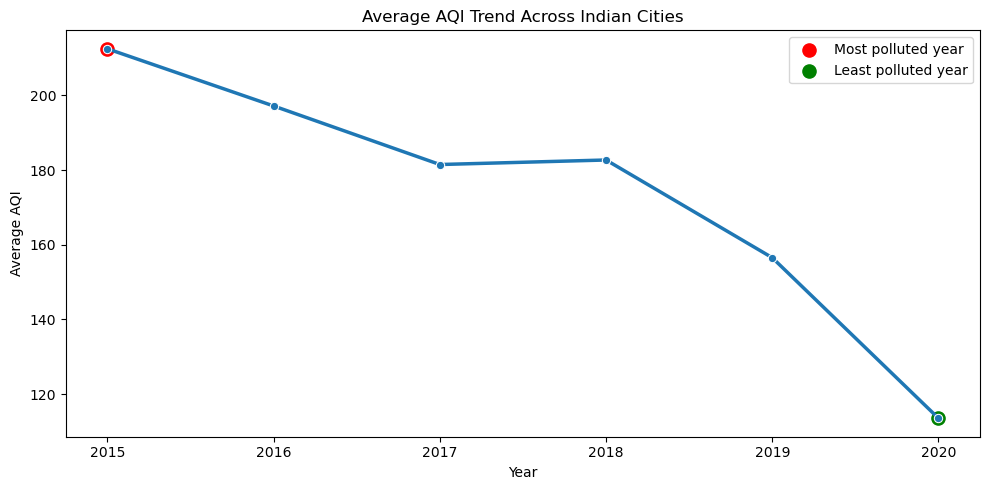

 Year        AQI
 2015 212.463054
 2016 197.150019
 2017 181.472789
 2018 182.684312
 2019 156.518173
 2020 113.520697
Most polluted year: 2015 Average AQI: 212.46
Least polluted year: 2020 Average AQI: 113.52


In [3]:
yearly_aqi = city.groupby("Year", as_index=False)["AQI"].mean()
most_polluted_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmin()]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_aqi, x="Year", y="AQI", marker="o", linewidth=2.5)
plt.scatter(most_polluted_year["Year"], most_polluted_year["AQI"], color="red", s=90, label="Most polluted year")
plt.scatter(least_polluted_year["Year"], least_polluted_year["AQI"], color="green", s=90, label="Least polluted year")
plt.title("Average AQI Trend Across Indian Cities")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(yearly_aqi["Year"])
plt.legend()
plt.tight_layout()
plt.show()

print(yearly_aqi.to_string(index=False))
print("Most polluted year:", int(most_polluted_year["Year"]), "Average AQI:", round(most_polluted_year["AQI"], 2))
print("Least polluted year:", int(least_polluted_year["Year"]), "Average AQI:", round(least_polluted_year["AQI"], 2))

Response to the journalist
The data suggests that average air quality improved after the highest pollution years in the middle of the period. The most polluted year in this dataset is highlighted in red and the least polluted year is highlighted in green. After 2018, the average AQI moves downward rather than upward, which suggests an improvement in measured city air quality. This does not prove that government policies alone caused the change, because weather, monitoring coverage, traffic, industry, lockdown effects, and other factors can also affect AQI.

Task 7: Farmers say the air is worst exactly when they harvest. Is that true?

c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


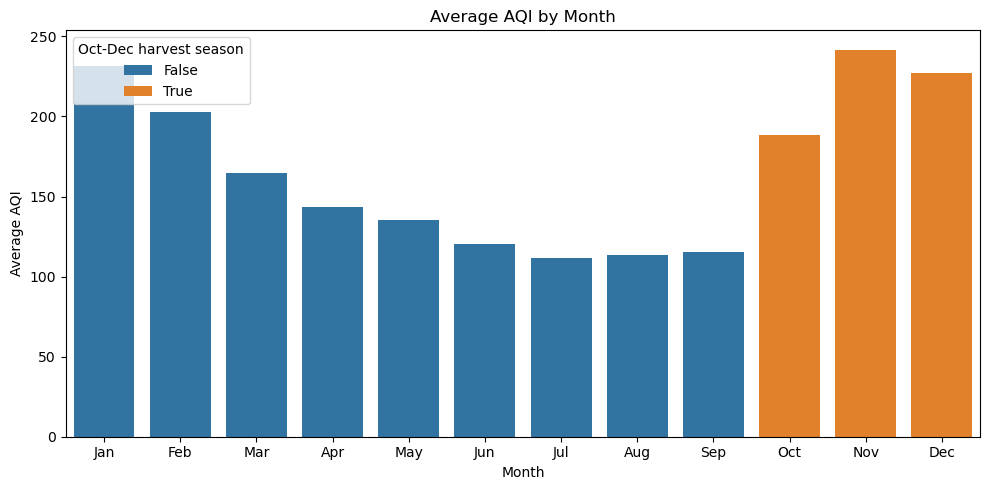

Month_Name        AQI  Harvest_Season
       Jan 231.674918           False
       Feb 202.905197           False
       Mar 164.735281           False
       Apr 143.355120           False
       May 135.489579           False
       Jun 120.198379           False
       Jul 111.854575           False
       Aug 113.613176           False
       Sep 115.191804           False
       Oct 188.613552            True
       Nov 241.681302            True
       Dec 227.084980            True
Oct-Dec average AQI: 219.49
Other months average AQI: 150.14


In [4]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_aqi = city.groupby("Month", as_index=False)["AQI"].mean()
monthly_aqi["Month_Name"] = pd.Categorical(
    pd.to_datetime(monthly_aqi["Month"], format="%m").dt.month_name().str[:3],
    categories=month_order,
    ordered=True
)
monthly_aqi = monthly_aqi.sort_values("Month")
monthly_aqi["Harvest_Season"] = monthly_aqi["Month"].isin([10, 11, 12])

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_aqi, x="Month_Name", y="AQI", hue="Harvest_Season", dodge=False)
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.legend(title="Oct-Dec harvest season")
plt.tight_layout()
plt.show()

harvest_avg = city.loc[city["Month"].isin([10, 11, 12]), "AQI"].mean()
other_avg = city.loc[~city["Month"].isin([10, 11, 12]), "AQI"].mean()

print(monthly_aqi[["Month_Name", "AQI", "Harvest_Season"]].to_string(index=False))
print("Oct-Dec average AQI:", round(harvest_avg, 2))
print("Other months average AQI:", round(other_avg, 2))

Response to the NGO: The claim is broadly supported by the data. AQI is visibly higher during October to December than during most other months, and the average AQI for the harvest-season months is higher than the average for the rest of the year. This pattern is consistent with the concern about crop residue burning, but the dataset by itself cannot prove that burning is the cause because it does not include wind, rainfall, fire incidents, local industry, or traffic conditions.

Task 8: Can the two datasets talk to each other?

Before merging, both files must be brought to the same level. The air-quality file is city-day data from 2015 to 2020, while the crop file is state-district-crop data from 1997 to 2015. If we merge on both state and year, only 2015 overlaps, which is too little for a useful correlation matrix. So the safer transformation here is to aggregate both datasets to state level, then merge on `State`. This compares each state's average air quality with its long-run agricultural output pattern.

In [5]:
state_aqi = city.groupby("State", as_index=False).agg(
    Mean_AQI=("AQI", "mean"),
    Median_AQI=("AQI", "median"),
    AQI_Records=("AQI", "count"),
    Cities_Covered=("City", "nunique")
)

state_crop = crop.groupby("State", as_index=False).agg(
    Total_Area=("Area", "sum"),
    Total_Production=("Production", "sum"),
    Crop_Records=("Production", "count"),
    Crop_Count=("Crop", "nunique"),
    Years_Covered=("Crop_Year", "nunique")
)
state_crop["Yield"] = state_crop["Total_Production"] / state_crop["Total_Area"]

merged = pd.merge(state_aqi, state_crop, on="State", how="inner")

print("Merged shape:", merged.shape)
print("Merged states:", merged["State"].nunique())
print(merged.head().to_string(index=False))

Merged shape: (20, 11)
Merged states: 20
         State   Mean_AQI  Median_AQI  AQI_Records  Cities_Covered  Total_Area  Total_Production  Crop_Records  Crop_Count  Years_Covered      Yield
Andhra Pradesh 108.086481        98.0         2012               2 131545844.0      1.732462e+10          9628          69             18 131.700236
         Assam 140.111111        98.0          495               1  70378758.0      2.111752e+09         14628          39             18  30.005528
         Bihar 240.782042       215.0         1459               1 128272031.0      3.665033e+08         18885          42             18   2.857235
    Chandigarh  96.498328        82.0          299               1     12522.0      6.400050e+04            90          12             13   5.111045
       Gujarat 452.122939       384.5         1334               1 154944024.0      5.243515e+08          8436          32             16   3.384135


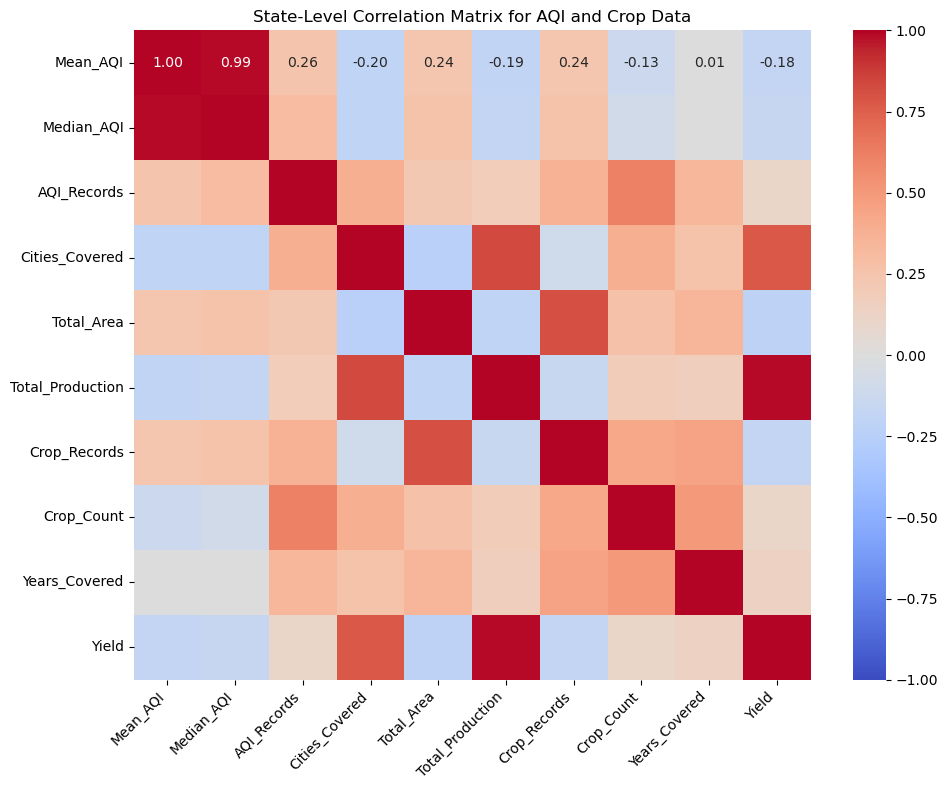

                  Mean_AQI  Median_AQI  AQI_Records  Cities_Covered  Total_Area  Total_Production  Crop_Records  Crop_Count  Years_Covered     Yield
Mean_AQI          1.000000    0.990720     0.257175       -0.202408    0.241767         -0.192188      0.240837   -0.129759       0.006734 -0.179046
Median_AQI        0.990720    1.000000     0.308907       -0.196644    0.265053         -0.172603      0.261950   -0.089308       0.004338 -0.161669
AQI_Records       0.257175    0.308907     1.000000        0.387244    0.221438          0.185352      0.373137    0.616253       0.339366  0.106388
Cities_Covered   -0.202408   -0.196644     0.387244        1.000000   -0.236079          0.833868     -0.094813    0.388434       0.263058  0.776260
Total_Area        0.241767    0.265053     0.221438       -0.236079    1.000000         -0.198845      0.807219    0.270503       0.348267 -0.214921
Total_Production -0.192188   -0.172603     0.185352        0.833868   -0.198845          1.000000     -0.1

In [6]:
numeric_cols = [
    "Mean_AQI", "Median_AQI", "AQI_Records", "Cities_Covered",
    "Total_Area", "Total_Production", "Crop_Records", "Crop_Count",
    "Years_Covered", "Yield"
]
corr = merged[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("State-Level Correlation Matrix for AQI and Crop Data")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(corr.to_string())

Two interesting relationships
1. `Total_Area` and `Total_Production` are strongly related. This is expected because states cultivating more land generally produce more crop in total, even if their productivity per hectare is not always better.
2. `Mean_AQI` and crop output measures show a weaker relationship than area and production. This suggests pollution may be connected to agricultural outcomes, but the relationship is not strong enough to treat AQI as the only explanation. Crop output also depends on rainfall, irrigation, soil quality, crop mix, technology, and market conditions.

Task 9: Briefing for the State Environment Minister

Minister, the data shows three important findings. First, city air quality appears to improve after the worst years in the middle of the period, especially after 2018, although the data cannot prove that policy alone caused this change. Second, air pollution is noticeably worse in October to December, which is the same period when many farmers harvest and crop residue burning becomes a public concern. Third, when air and crop data are compared at state-year level, crop production is more strongly linked with how much land is cultivated than with average AQI alone.

What this means on the ground is that farmers and cities may both be affected during the same seasonal pollution window, but crop loss cannot be blamed on air pollution alone from this dataset. My recommendation is to target October to December with residue-management support, faster collection of crop waste, and incentives for alternatives to burning. The honest limitation is that this data does not include rainfall, irrigation, soil quality, fires, or local industry, so it shows patterns, not final proof of cause.

Task A: The two pollution extremes

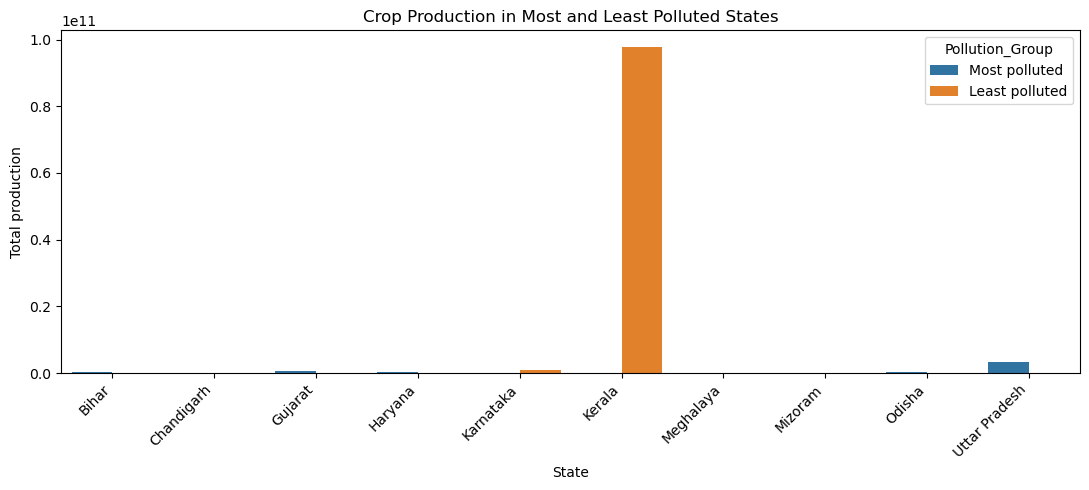

Least polluted states: ['Mizoram', 'Meghalaya', 'Kerala', 'Karnataka', 'Chandigarh']
Most polluted states: ['Gujarat', 'Bihar', 'Haryana', 'Uttar Pradesh', 'Odisha']
Pollution_Group         State   Mean_AQI  Total_Production       Yield
 Least polluted       Mizoram  34.765766      1.662340e+06    1.672820
 Least polluted     Meghalaya  53.795122      1.211250e+07    3.001837
 Least polluted        Kerala  81.021277      9.788011e+10 3067.565616
 Least polluted     Karnataka  94.318325      8.634404e+08    4.255285
 Least polluted    Chandigarh  96.498328      6.400050e+04    5.111045
  Most polluted        Odisha 161.463501      1.609533e+08    1.456148
  Most polluted Uttar Pradesh 217.973059      3.234509e+09    7.459117
  Most polluted       Haryana 225.123882      3.952428e+08    4.411324
  Most polluted         Bihar 240.782042      3.665033e+08    2.857235
  Most polluted       Gujarat 452.122939      5.243515e+08    3.384135


In [7]:
state_aqi_rank = merged[["State", "Mean_AQI"]].copy()
low_states = state_aqi_rank.nsmallest(5, "Mean_AQI")["State"]
high_states = state_aqi_rank.nlargest(5, "Mean_AQI")["State"]
extreme_states = pd.concat([low_states, high_states])

extreme_data = merged[merged["State"].isin(extreme_states)].copy()
extreme_data["Pollution_Group"] = np.where(extreme_data["State"].isin(high_states), "Most polluted", "Least polluted")

plt.figure(figsize=(11, 5))
sns.barplot(data=extreme_data, x="State", y="Total_Production", hue="Pollution_Group", errorbar=None)
plt.title("Crop Production in Most and Least Polluted States")
plt.xlabel("State")
plt.ylabel("Total production")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Least polluted states:", low_states.tolist())
print("Most polluted states:", high_states.tolist())
print(extreme_data[["Pollution_Group", "State", "Mean_AQI", "Total_Production", "Yield"]].sort_values(["Pollution_Group", "Mean_AQI"]).to_string(index=False))

The extreme-state comparison makes the hypothesis more complicated rather than proving it. Some highly polluted states still have large crop production because they also cultivate large areas or grow high-output crops. This means pollution may matter, but total production is also shaped by land area, irrigation, crop choice, rainfall, and farming infrastructure.

Task B: Put a number on the relationship

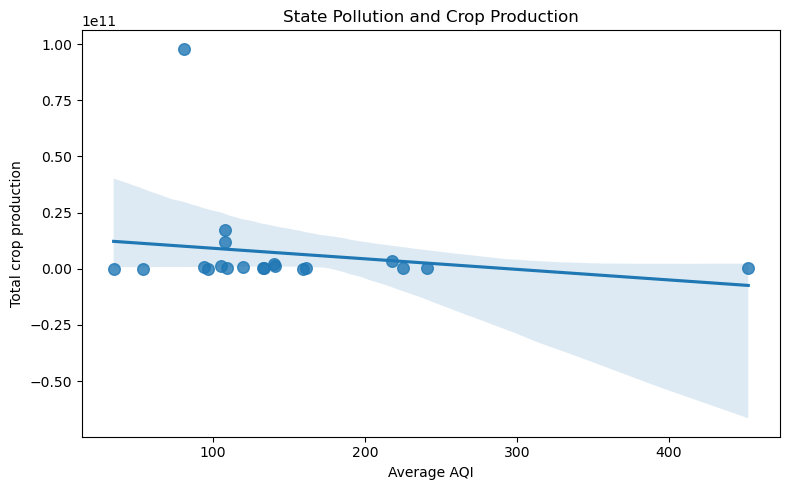

Correlation between AQI and production: -0.192
Correlation between AQI and yield: -0.179
         State   Mean_AQI  Avg_Production   Avg_Yield
Andhra Pradesh 108.086481    1.732462e+10  131.700236
         Assam 140.111111    2.111752e+09   30.005528
         Bihar 240.782042    3.665033e+08    2.857235
    Chandigarh  96.498328    6.400050e+04    5.111045
       Gujarat 452.122939    5.243515e+08    3.384135
       Haryana 225.123882    3.952428e+08    4.411324
     Jharkhand 159.251621    1.077774e+07    1.147661
     Karnataka  94.318325    8.634404e+08    4.255285
        Kerala  81.021277    9.788011e+10 3067.565616
Madhya Pradesh 132.827338    4.491553e+08    1.361848
   Maharashtra 105.352258    1.263771e+09    3.922243
     Meghalaya  53.795122    1.211250e+07    3.001837
       Mizoram  34.765766    1.662340e+06    1.672820
        Odisha 161.463501    1.609533e+08    1.456148
        Punjab 119.920959    5.863926e+08    4.627263
     Rajasthan 133.679159    2.816623e+08    1.

In [8]:
state_summary = merged[["State", "Mean_AQI", "Total_Production", "Yield"]].copy()
state_summary = state_summary.rename(columns={"Total_Production": "Avg_Production", "Yield": "Avg_Yield"})

corr_aqi_production = state_summary["Mean_AQI"].corr(state_summary["Avg_Production"])
corr_aqi_yield = state_summary["Mean_AQI"].corr(state_summary["Avg_Yield"])

plt.figure(figsize=(8, 5))
sns.regplot(data=state_summary, x="Mean_AQI", y="Avg_Production", scatter_kws={"s": 70})
plt.title("State Pollution and Crop Production")
plt.xlabel("Average AQI")
plt.ylabel("Total crop production")
plt.tight_layout()
plt.show()

print("Correlation between AQI and production:", round(corr_aqi_production, 3))
print("Correlation between AQI and yield:", round(corr_aqi_yield, 3))
print(state_summary.to_string(index=False))

The correlation gives the direction and strength of the relationship, but it does not prove cause. A weak or moderate value means AQI and crop production move together only partly, while a strong value would suggest a clearer pattern. Even if the value is noticeable, it could still be explained by rainfall, irrigation, soil type, crop choices, economic conditions, or state size.

Task C: One plot to rule them all

The strongest single chart is the monthly AQI bar chart from Task 7. It matters because it turns a broad pollution problem into a clear seasonal policy window: October to December stands out as the period when intervention is most urgent. This chart is more actionable than a yearly trend because it tells policymakers when to prepare support for farmers and cities. It still does not prove crop burning is the only cause, but it shows exactly when the air-quality burden becomes heavier.

Conclusion / Inference

Lab 2 showed that India's city-level AQI in this dataset generally improved over time, with 2015 having the highest average AQI and 2020 having the lowest average AQI. Monthly analysis also showed a clear seasonal pattern: AQI was higher during October to December, which supports the concern that the harvest period overlaps with worse air quality. However, the state-level comparison between AQI and crop production showed only weak negative correlations with production and yield. This means polluted states do not always have low crop output, because agricultural production is also strongly influenced by cultivated area, crop type, rainfall, irrigation, soil quality, and farming infrastructure. Therefore, the dataset suggests a relationship between seasonal pollution and agriculture, but it does not prove that air pollution alone directly reduces crop production.

Combined Conclusion / Inference from Lab 1 and Lab 2

Together, Lab 1 and Lab 2 show the full data-analysis process: first cleaning and preparing imperfect real-world datasets, then using them to identify meaningful patterns. Lab 1 made the AQI and crop-production data usable by handling missing values, state-name inconsistencies, duplicates, skewness, and outliers. Lab 2 then used the cleaned structure to show that AQI declined over the years, pollution was worse during the harvest-season months, and the AQI-crop relationship was present but weak at the state level. The combined inference is that air pollution and agriculture are connected mainly through seasonal and regional patterns, but crop production cannot be explained by AQI alone. Better conclusions would require additional variables such as rainfall, irrigation, crop-burning incidents, wind direction, industrial activity, and district-level air-quality data.